In [1]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [11]:
data_flag = 'dermamnist'
# data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [5]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 19.7M/19.7M [00:01<00:00, 10.4MB/s]


In [12]:
print(info)

{'python_class': 'DermaMNIST', 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1', 'MD5': '0744692d530f8e62ec473284d019b0c7', 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1', 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f', 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1', 'MD5_128': '2defd784463fa5243564e855ed717de1', 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1', 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d', 'task': 'multi-class', 'la

In [6]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /home/dbiparva/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapo

In [7]:
# visualization

train_dataset.montage(length=1)

In [8]:
n_channels

3

In [9]:
n_classes

7

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([128, 3, 28, 28])
torch.Size([128, 1])


In [13]:
# define a simple CNN model

class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Net(in_channels=n_channels, num_classes=n_classes)
    
# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()
    
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [14]:
# train

for epoch in range(NUM_EPOCHS):
    train_correct = 0
    train_total = 0
    test_correct = 0
    test_total = 0
    
    model.train()
    for inputs, targets in tqdm(train_loader):
        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(inputs)
        
        if task == 'multi-label, binary-class':
            targets = targets.to(torch.float32)
            loss = criterion(outputs, targets)
        else:
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

100%|██████████| 55/55 [00:03<00:00, 17.07it/s]


In [15]:
# evaluation

def test(split):
    model.eval()
    y_true = torch.tensor([])
    y_score = torch.tensor([])
    
    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze().long()
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)

            y_true = torch.cat((y_true, targets), 0)
            y_score = torch.cat((y_score, outputs), 0)

        y_true = y_true.numpy()
        y_score = y_score.detach().numpy()
        
        evaluator = Evaluator(data_flag, split)
        metrics = evaluator.evaluate(y_score)
    
        print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))

        
print('==> Evaluating ...')
test('train')
test('test')

==> Evaluating ...
train  auc: 0.826  acc:0.670
test  auc: 0.826  acc:0.669


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ----------------
        # Encoder: 3x3 kernels, gradual downsampling
        # ----------------
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # 3x28x28 -> 32x28x28
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 32x28x28 -> 64x14x14
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 64x14x14 -> 128x7x7
            nn.ReLU()
        )

        # Flatten for latent vectors
        self.fc_mu = nn.Linear(128*7*7, latent_dim)
        self.fc_logvar = nn.Linear(128*7*7, latent_dim)

        # ----------------
        # Decoder: mirror encoder
        # ----------------
        self.fc_decode = nn.Linear(latent_dim, 128*7*7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # 128x7x7 -> 64x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64x14x14 -> 32x28x28
            nn.ReLU(),
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),                                # 32x28x28 -> 3x28x28
            nn.Tanh()  # match input normalization [-1,1]
        )

    # ----------------
    # Forward passes
    # ----------------
    def encode(self, x):
        h = self.encoder(x)
        h = h.flatten(start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss +  kld, recon_loss, kld

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30
train_total_losses = []
train_recon_losses = []
train_kld_losses = []
for epoch in range(epochs):
    model.train()
    
    total_loss_epoch = 0
    recon_loss_epoch = 0
    kld_loss_epoch = 0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        
        loss, recon_loss, kld = vae_loss(recon, images, mu, logvar)
        
        loss.backward()
        optimizer.step()
        
        total_loss_epoch += loss.item()
        recon_loss_epoch += recon_loss.item()
        kld_loss_epoch += kld.item()
    
    # Normalize by dataset size
    dataset_size = len(train_loader.dataset)
    
    train_total_losses.append(total_loss_epoch / dataset_size)
    train_recon_losses.append(recon_loss_epoch / dataset_size)
    train_kld_losses.append(kld_loss_epoch / dataset_size)
    
    print(f"Epoch {epoch+1}: "
          f"Total={train_total_losses[-1]:.4f} | "
          f"Recon={train_recon_losses[-1]:.4f} | "
          f"KLD={train_kld_losses[-1]:.4f}")

Epoch 1: Total=198.8304 | Recon=188.3233 | KLD=5.2535
Epoch 2: Total=100.6681 | Recon=80.5899 | KLD=10.0391
Epoch 3: Total=75.4421 | Recon=51.9261 | KLD=11.7580
Epoch 4: Total=68.3002 | Recon=45.2662 | KLD=11.5170
Epoch 5: Total=63.5350 | Recon=40.8951 | KLD=11.3199
Epoch 6: Total=60.8860 | Recon=38.6676 | KLD=11.1092
Epoch 7: Total=59.6813 | Recon=37.5855 | KLD=11.0479
Epoch 8: Total=59.0992 | Recon=37.1420 | KLD=10.9786
Epoch 9: Total=58.1601 | Recon=36.2422 | KLD=10.9589
Epoch 10: Total=57.3911 | Recon=35.5316 | KLD=10.9297
Epoch 11: Total=56.9052 | Recon=35.0584 | KLD=10.9234
Epoch 12: Total=56.5844 | Recon=34.7640 | KLD=10.9102
Epoch 13: Total=56.1857 | Recon=34.2726 | KLD=10.9566
Epoch 14: Total=55.9256 | Recon=34.0123 | KLD=10.9567
Epoch 15: Total=55.8106 | Recon=33.8452 | KLD=10.9827
Epoch 16: Total=55.3615 | Recon=33.3603 | KLD=11.0006
Epoch 17: Total=55.2000 | Recon=33.3255 | KLD=10.9373
Epoch 18: Total=54.9995 | Recon=33.0543 | KLD=10.9726
Epoch 19: Total=54.9159 | Recon=33.

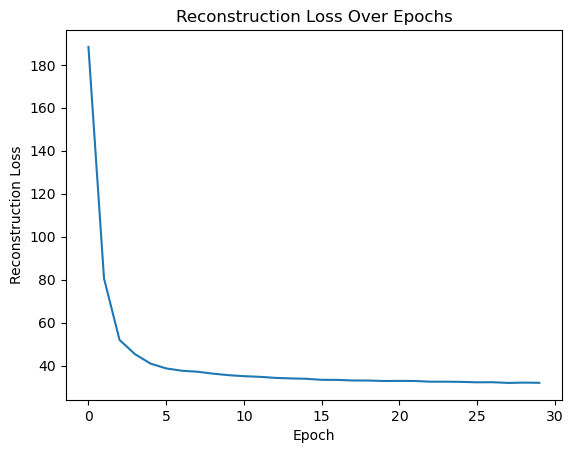

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_recon_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss Over Epochs")
plt.show()

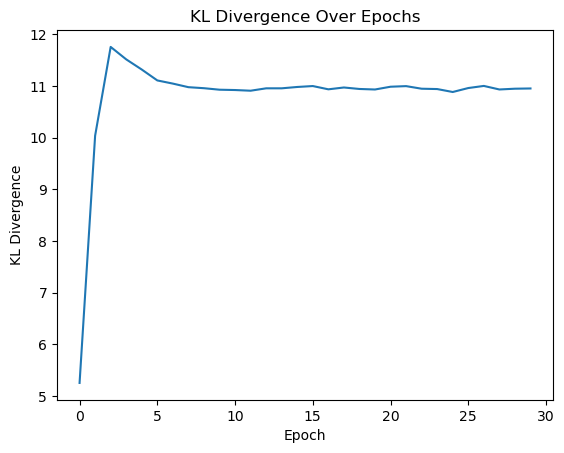

In [49]:
plt.figure()
plt.plot(train_kld_losses)
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("KL Divergence Over Epochs")
plt.show()

In [50]:
def denormalize(x):
    return x * 0.5 + 0.5

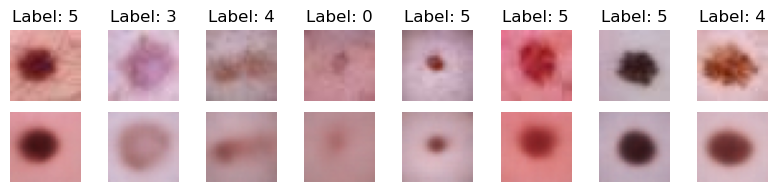

In [51]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    recon, _, _ = model(images)

# Move to CPU
images = images.cpu()
recon = recon.cpu()

# Denormalize
images = images * 0.5 + 0.5
recon = recon * 0.5 + 0.5

N = 8
fig, axes = plt.subplots(2, N, figsize=(1*N, 2))

for i in range(N):
    axes[0, i].imshow(images[i].permute(1,2,0))
    axes[0, i].set_title(f"Label: {labels[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].permute(1,2,0))
    axes[1, i].axis("off")

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Reconstruction")

plt.tight_layout()
plt.show()